In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import ScalarFormatter
from pylab import rc
from pathlib import Path

Average IE over the last 300 ns of the final plot: -90348.78 kJ/mol


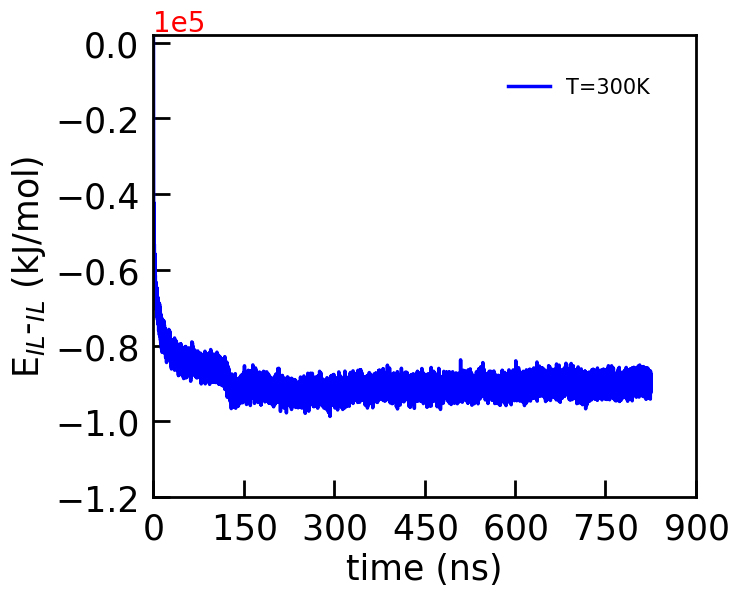

In [15]:
# Setup
rc('axes', linewidth=2.0)
fig = plt.figure(1034, figsize=(7, 6))
ax = fig.add_subplot(111)

# File base path and filenames
base_path = Path("/media/sukanya/SSD2/PolyParGen-CG-p123/change-beads-polymer-emim-dca-IL/mod-sigma-epsilon-TN2ar-C3-Q5-beads/test-interaction-cation-C3-bead/C3-cation-9/phase-seperation-pluronic-emim-dca/15nm-box-60per-IL-40per-pluronic/rerun/interaction-energy")
files = [
    "IL-IL-LJ-equil3.xvg",
    "IL-IL-LJ-equil4.xvg",
    "IL-IL-LJ-equil5.xvg", 
    "IL-IL-LJ-equil6.xvg",
    "IL-IL-LJ-equil7.xvg",
    "IL-IL-LJ-equil8.xvg",
    "IL-IL-LJ-equil9.xvg",
    "IL-IL-LJ-equil10.xvg"
]

# Time offset adjustments per file (adjusted manually as in original script)
time_offsets = [-100, 25, 25, 25, 25, 25, 25, 25]  # ns

# List to collect final plotted data
combined_data = []

# Loop through files
for i, (filename, offset) in enumerate(zip(files, time_offsets)):
    file_path = base_path / filename
    data = pd.read_csv(file_path, names=["time", "IE"], sep=r'\s+', skiprows=24)
    ##data["IE_smooth"] = data["IE"].rolling(window=100, center=True).mean()
    data["time_ns_offset"] = data["time"] * 0.001 + offset
    
    # Store only valid smoothed data for averaging
    valid_data = data[["time_ns_offset", "IE"]].dropna()
    combined_data.append(valid_data)
    
    label = "T=300K" if i == 0 else None  # Label only once for the legend
    plt.plot(valid_data["time_ns_offset"], valid_data["IE"], color='b', linewidth=2.5, label=label)

# Concatenate all plotted data
final_plot_data = pd.concat(combined_data, ignore_index=True)
max_time = final_plot_data["time_ns_offset"].max()# Filter to last 300 ns
# Filter to last 300 ns
last_300ns_data = final_plot_data[final_plot_data["time_ns_offset"] >= (max_time - 300)]
# Compute average IE over that region
average_IE = last_300ns_data["IE"].mean()
print(f"Average IE over the last 300 ns of the final plot: {average_IE:.2f} kJ/mol")
np.savetxt('data_LJ.txt', [average_IE])

# Axis labels and ticks
plt.ylabel(r'E$_{IL}$-$_{IL}$ (kJ/mol)', fontsize=25, labelpad=5, fontname='DejaVu Sans')
plt.xlabel('time (ns)', fontsize=25, labelpad=5, fontname='DejaVu Sans')
plt.ylim([-120000.0, 2000.00])
plt.xlim([0.0, 900.01])
plt.xticks(np.arange(0, 901, 150), fontsize=25, fontname='DejaVu Sans')
plt.yticks(np.arange(-120000.0, 2000, 20000), fontsize=25, fontname='DejaVu Sans')
# Legend and formatting
plt.legend(fontsize=15, bbox_to_anchor=(0.95, 0.95), loc='upper right', edgecolor='white')
plt.tick_params(axis='both', which='major', length=12, direction='in', width=2, labelsize=25, pad=10)
ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(5, 5))

# Customize scientific offset text
offset_text = ax.yaxis.get_offset_text()
offset_text.set_size(20)
offset_text.set_color('red')

# Save and show
plt.savefig(base_path / "IE-IL-IL-LJ.png", bbox_inches='tight', dpi=600)
plt.show()